In [1]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from qutip.ipynbtools import version_table
from tqdm.notebook import tqdm


resol = 300
pi = np.pi
version_table()

Software,Version
QuTiP,5.1.1
Numpy,1.26.2
SciPy,1.11.3
matplotlib,3.7.3
Number of CPUs,11
BLAS Info,Generic
IPython,8.17.2
Python,"3.12.0 (v3.12.0:0fb18b02c8, Oct 2 2023, 09:45:56) [Clang 13.0.0 (clang-1300.0.29.30)]"
OS,posix [darwin]
Cython,3.0.11


<h1> Fix problem parameters </h1>

In [60]:
#atom and waveguide

omega_A = 10*pi
Gamma = pi
omega_ref = 0.99*omega_A

Try to invert the renormalization relations

In [61]:
def get_dw0(lbda):
    dwA = omega_A - omega_ref
    dw0_inf = -1*lbda
    dw0_sup = lbda
    residual_diff = np.inf

    while np.abs(residual_diff) > 1e-4: #research by dichotomy

        dw0_guess = 0.5*(dw0_inf + dw0_sup)
        residual_diff = dwA - dw0_guess + Gamma * np.log((lbda-dw0_guess)/(lbda+dw0_guess)) 

        if residual_diff > 0:
            dw0_inf = dw0_guess
        else:
            dw0_sup = dw0_guess

    return dw0_guess, residual_diff

Test the function

In [62]:
get_dw0(9*pi)

(0.2570256715451824, 1.5204538915104815e-05)

Bare parameters against $\Lambda$

In [63]:
lbda_tab = np.linspace(pi, 9*pi, 100)
omega_0_tab = np.zeros(100)
gamma_tab = np.zeros(100)

for i in range(100):
    dw0, _ = get_dw0(lbda_tab[i])
    omega_0_tab[i] = omega_ref + dw0
    gamma_tab[i] = 1/(1/Gamma + lbda_tab[i] / (pi*(lbda_tab[i]**2 - dw0**2)))

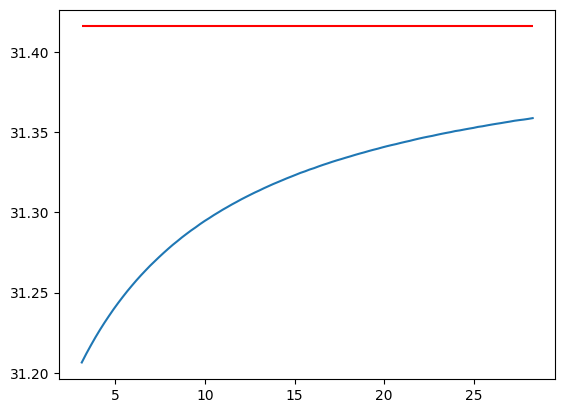

In [64]:
plt.plot(lbda_tab, omega_0_tab)
plt.hlines(y=omega_A,xmin=lbda_tab[0], xmax=lbda_tab[-1],color='red')
plt.show()

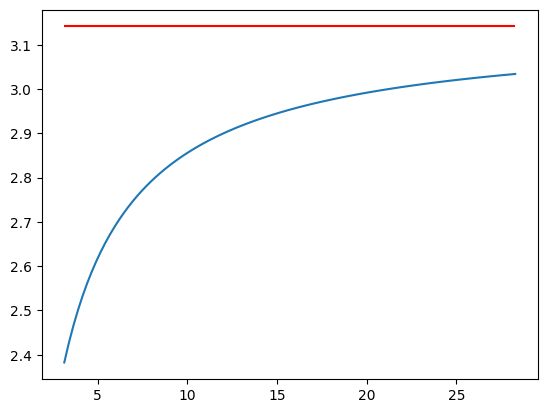

In [ ]:
plt.plot(lbda_tab, gamma_tab)
plt.hlines(y=Gamma,xmin=lbda_tab[0], xmax=lbda_tab[-1], color='red')
plt.show()